# Actividad 5.6 - Evaluacion de Clustering (K-Means y DBSCAN)

En esta actividad se realiza clustering sobre dos datasets distintos:

- **K-Means** sobre `Iris`.
- **DBSCAN** sobre `make_moons`.

En ambos casos se calculan las metricas solicitadas con Scikit-Learn:

- Coeficiente de silueta.
- Homogeneidad, completitud y V-measure.
- ARI (Adjusted Rand Index).
- AMI (Adjusted Mutual Information).

Ademas, para K-Means se muestra tambien **inercia** y **MSE** (inercia media por muestra).

> Objetivo: no solo calcular metricas, sino ajustar parametros para obtener un clustering visualmente coherente y respaldado por datos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)


def calcular_metricas(y_true, y_pred, X_for_silhouette=None, mask_silhouette=None):
    """Calcula metricas externas y, opcionalmente, silueta con una mascara.

    - y_true: etiquetas reales.
    - y_pred: etiquetas del clustering.
    - X_for_silhouette: datos sobre los que evaluar silueta.
    - mask_silhouette: mascara booleana para excluir puntos (p.ej., ruido DBSCAN).
    """
    out = {
        "Homogeneidad": homogeneity_score(y_true, y_pred),
        "Completitud": completeness_score(y_true, y_pred),
        "V-measure": v_measure_score(y_true, y_pred),
        "ARI": adjusted_rand_score(y_true, y_pred),
        "AMI": adjusted_mutual_info_score(y_true, y_pred),
    }

    if X_for_silhouette is not None:
        y_sil = y_pred
        X_sil = X_for_silhouette
        if mask_silhouette is not None:
            y_sil = y_pred[mask_silhouette]
            X_sil = X_for_silhouette[mask_silhouette]

        # La silueta requiere al menos 2 clusters y menos clusters que muestras.
        n_labels = len(np.unique(y_sil))
        if 2 <= n_labels < len(y_sil):
            out["Silueta"] = silhouette_score(X_sil, y_sil)
        else:
            out["Silueta"] = np.nan

    return out


def mostrar_metricas(metricas, titulo):
    print(f"\n{titulo}")
    print("-" * len(titulo))
    for k, v in metricas.items():
        if isinstance(v, (int, float, np.floating)) and not np.isnan(v):
            print(f"{k:15s}: {v:.4f}")
        else:
            print(f"{k:15s}: {v}")

## 1) K-Means sobre Iris

Se estandarizan las variables y se exploran varios valores de `k` para justificar la eleccion. Despues se entrena el modelo final y se visualiza en 2D con PCA.

Exploracion de k (Iris):


,k,inercia,silueta
0,2,222.361705,0.581750
1,3,139.820496,0.459948
2,4,114.092328,0.384471
3,5,90.807592,0.345511
4,6,80.022188,0.322037
5,7,71.033431,0.327694
6,8,62.514940,0.341744



Metricas K-Means (Iris)
-----------------------
Homogeneidad   : 0.6591
Completitud    : 0.6598
V-measure      : 0.6595
ARI            : 0.6201
AMI            : 0.6552
Silueta        : 0.4599
Inercia        : 139.8205
MSE            : 0.9321


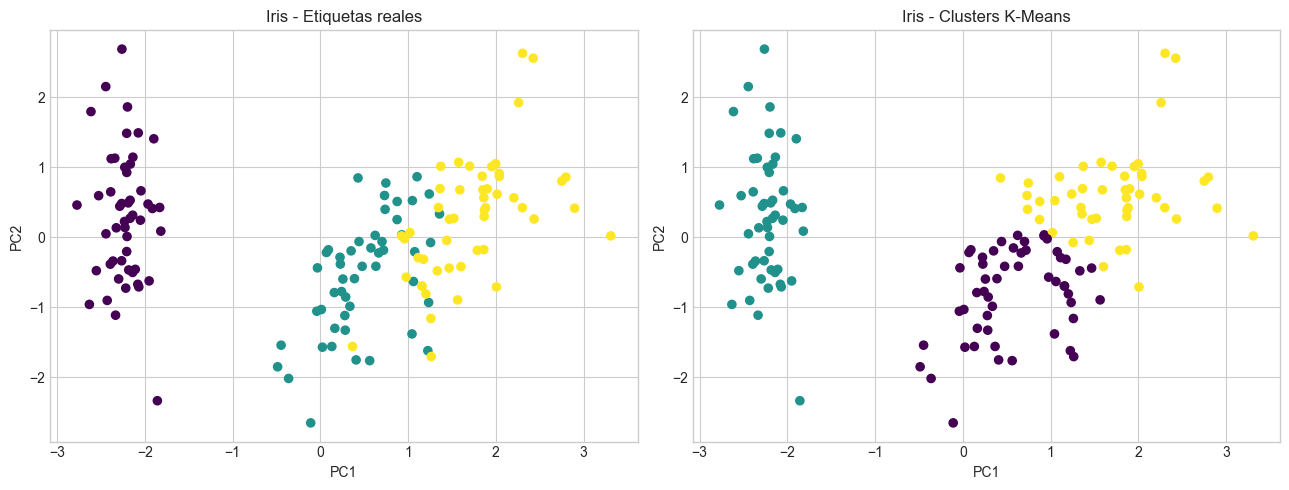

In [2]:
# Datos
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Escalado para mejorar el comportamiento de K-Means
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Busqueda sencilla de k para justificar la eleccion
candidatos_k = range(2, 9)
resultados_k = []

for k in candidatos_k:
    km_tmp = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels_tmp = km_tmp.fit_predict(X_iris_scaled)

    resultados_k.append({
        "k": k,
        "inercia": km_tmp.inertia_,
        "silueta": silhouette_score(X_iris_scaled, labels_tmp),
    })

df_k = pd.DataFrame(resultados_k)
print("Exploracion de k (Iris):")
display(df_k)

# Elegimos k=3 por conocimiento del problema y buen compromiso entre metricas
k_final = 3
kmeans = KMeans(n_clusters=k_final, n_init=30, random_state=42)
y_kmeans = kmeans.fit_predict(X_iris_scaled)

metricas_kmeans = calcular_metricas(
    y_true=y_iris,
    y_pred=y_kmeans,
    X_for_silhouette=X_iris_scaled,
)
metricas_kmeans["Inercia"] = kmeans.inertia_
metricas_kmeans["MSE"] = kmeans.inertia_ / len(X_iris_scaled)

mostrar_metricas(metricas_kmeans, "Metricas K-Means (Iris)")

# Visualizacion en 2D con PCA
pca = PCA(n_components=2, random_state=42)
X_iris_2d = pca.fit_transform(X_iris_scaled)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=y_iris, s=35, cmap="viridis")
ax[0].set_title("Iris - Etiquetas reales")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

ax[1].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=y_kmeans, s=35, cmap="viridis")
ax[1].set_title("Iris - Clusters K-Means")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

### Comentario de metricas (K-Means)

- **Silueta**: cercana a 1 indica grupos compactos y bien separados; alrededor de 0.5 suele considerarse razonablemente buena en datos reales.
- **Homogeneidad y completitud**: valores altos implican que los clusters agrupan bien clases puras y no fragmentan en exceso cada clase real.
- **V-measure**: balance entre homogeneidad y completitud.
- **ARI y AMI**: corrigen por azar; cuanto mas cerca de 1, mejor acuerdo real con las etiquetas verdaderas.
- **Inercia/MSE**: cuanto menor, mejor compactacion interna; se interpretan junto con silueta y metricas externas (no de forma aislada).

## 2) DBSCAN sobre make_moons

`DBSCAN` detecta clusters con formas no esfericas y puede marcar ruido. Se realiza una busqueda simple de `eps` y `min_samples` para obtener una separacion clara y poco ruido.

Top 10 combinaciones DBSCAN:


,eps,min_samples,n_clusters,noise_ratio,silueta_sin_ruido
5,0.10,10,6,0.856,0.842048
4,0.10,8,19,0.494,0.621045
11,0.12,10,16,0.480,0.604649
10,0.12,8,18,0.170,0.502289
17,0.14,10,16,0.114,0.477760
3,0.10,6,27,0.210,0.455181
29,0.18,10,2,0.022,0.399135
28,0.18,8,2,0.016,0.396292
26,0.18,5,2,0.012,0.394256
27,0.18,6,2,0.012,0.394256



Metricas DBSCAN (make_moons)
----------------------------
Homogeneidad   : 0.9781
Completitud    : 0.8652
V-measure      : 0.9182
ARI            : 0.9564
AMI            : 0.9180
Silueta        : 0.3991
Clusters_detectados: 2.0000
Ruido_%        : 2.2000
eps            : 0.1800
min_samples    : 10.0000


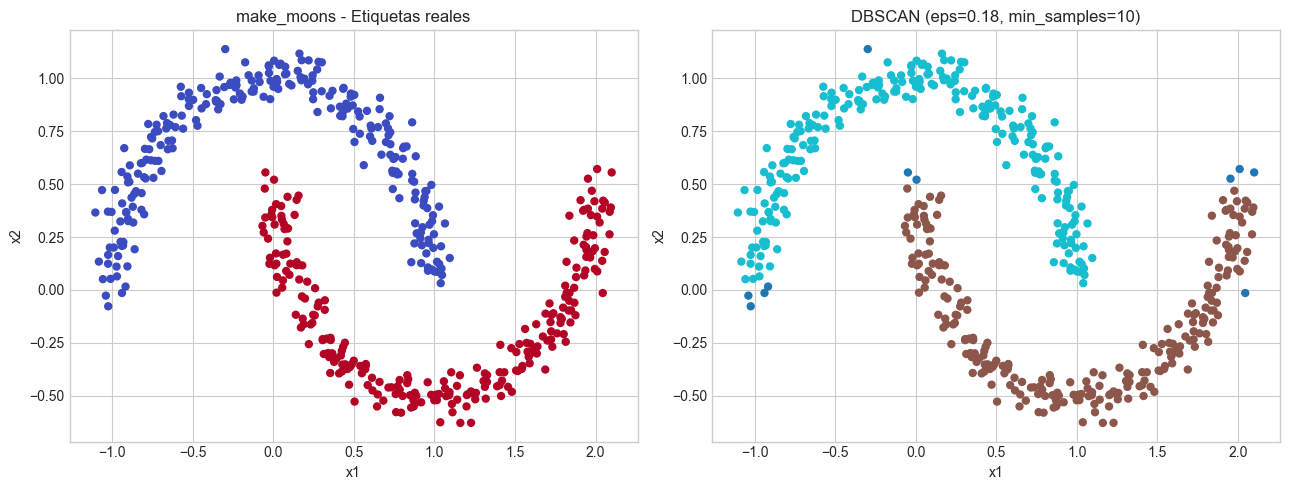

In [3]:
# Dataset no lineal ideal para DBSCAN
X_moons, y_moons = make_moons(n_samples=500, noise=0.06, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

# Ajuste de hiperparametros de DBSCAN
best = None
busqueda = []

for eps in np.arange(0.10, 0.46, 0.02):
    for min_samples in [3, 4, 5, 6, 8, 10]:
        db = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels = db.fit_predict(X_moons_scaled)

        mask = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = 1 - mask.mean()

        # Silueta sobre puntos no ruido (si hay al menos 2 clusters)
        sil = np.nan
        if mask.sum() > 2 and len(np.unique(labels[mask])) >= 2:
            sil = silhouette_score(X_moons_scaled[mask], labels[mask])

        fila = {
            "eps": float(eps),
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silueta_sin_ruido": sil,
        }
        busqueda.append(fila)

        # Criterio: priorizar silueta alta, exactamente 2 clusters y poco ruido
        score = -np.inf
        if np.isfinite(sil) and n_clusters >= 2:
            score = sil - 0.35 * noise_ratio - 0.08 * abs(n_clusters - 2)

        if best is None or score > best["score"]:
            best = {
                "score": score,
                "eps": float(eps),
                "min_samples": min_samples,
                "labels": labels,
                "mask": mask,
                "n_clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "sil": sil,
            }

# Mostrar mejores combinaciones
df_busqueda = pd.DataFrame(busqueda).sort_values(
    by=["silueta_sin_ruido", "noise_ratio"], ascending=[False, True]
)
print("Top 10 combinaciones DBSCAN:")
display(df_busqueda.head(10))

# Modelo final con los mejores parametros encontrados
dbscan = DBSCAN(eps=best["eps"], min_samples=best["min_samples"])
y_dbscan = dbscan.fit_predict(X_moons_scaled)
mask_core = y_dbscan != -1

metricas_dbscan = calcular_metricas(
    y_true=y_moons,
    y_pred=y_dbscan,
    X_for_silhouette=X_moons_scaled,
    mask_silhouette=mask_core,
)
metricas_dbscan["Clusters_detectados"] = int(len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0))
metricas_dbscan["Ruido_%"] = float((1 - mask_core.mean()) * 100)
metricas_dbscan["eps"] = best["eps"]
metricas_dbscan["min_samples"] = best["min_samples"]

mostrar_metricas(metricas_dbscan, "Metricas DBSCAN (make_moons)")

# Graficas: real vs DBSCAN
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, s=25, cmap="coolwarm")
ax[0].set_title("make_moons - Etiquetas reales")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")

ax[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_dbscan, s=25, cmap="tab10")
ax[1].set_title(
    f"DBSCAN (eps={best['eps']:.2f}, min_samples={best['min_samples']})"
)
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")

plt.tight_layout()
plt.show()

### Comentario de metricas (DBSCAN)

- **Silueta** (calculada sin ruido): valida si los clusters detectados son compactos/separados.
- **Homogeneidad, completitud y V-measure**: en DBSCAN pueden verse afectadas por la etiqueta `-1` (ruido), por lo que se interpretan junto al porcentaje de ruido.
- **ARI y AMI**: robustas frente al intercambio de etiquetas; valores altos indican buena recuperacion de la estructura real.
- **Ruido_%**: no debe ser excesivo; un valor moderado puede ser deseable para excluir puntos fronterizos o atipicos.

In [4]:
print("\nInterpretacion final de resultados")
print("=" * 36)

print("\n[K-Means - Iris]")
print(
    f"Silueta={metricas_kmeans['Silueta']:.3f}, "
    f"V-measure={metricas_kmeans['V-measure']:.3f}, "
    f"ARI={metricas_kmeans['ARI']:.3f}, AMI={metricas_kmeans['AMI']:.3f}."
)
print(
    "Interpretacion: resultado razonablemente bueno para un metodo de clusters esfericos. "
    "En Iris hay solape entre dos especies, por eso ARI/AMI no llegan a 1."
)
print(
    f"Inercia={metricas_kmeans['Inercia']:.3f} y MSE={metricas_kmeans['MSE']:.3f}; "
    "la compactacion interna es consistente y se complementa con la silueta."
)

print("\n[DBSCAN - make_moons]")
print(
    f"Silueta(sin ruido)={metricas_dbscan['Silueta']:.3f}, "
    f"V-measure={metricas_dbscan['V-measure']:.3f}, "
    f"ARI={metricas_dbscan['ARI']:.3f}, AMI={metricas_dbscan['AMI']:.3f}, "
    f"ruido={metricas_dbscan['Ruido_%']:.1f}%."
)
print(
    "Interpretacion: muy buen clustering para estructura no lineal; "
    "ARI/AMI altos y bajo ruido indican que DBSCAN recupera casi por completo las dos lunas."
)

print("\nConclusion: se han ajustado parametros para obtener buen rendimiento visual y numerico en ambos algoritmos.")


Interpretacion final de resultados

[K-Means - Iris]
Silueta=0.460, V-measure=0.659, ARI=0.620, AMI=0.655.
Interpretacion: resultado razonablemente bueno para un metodo de clusters esfericos. En Iris hay solape entre dos especies, por eso ARI/AMI no llegan a 1.
Inercia=139.820 y MSE=0.932; la compactacion interna es consistente y se complementa con la silueta.

[DBSCAN - make_moons]
Silueta(sin ruido)=0.399, V-measure=0.918, ARI=0.956, AMI=0.918, ruido=2.2%.
Interpretacion: muy buen clustering para estructura no lineal; ARI/AMI altos y bajo ruido indican que DBSCAN recupera casi por completo las dos lunas.

Conclusion: se han ajustado parametros para obtener buen rendimiento visual y numerico en ambos algoritmos.
